In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# ***Q1. (Data Loading & Initial Analysis)***

In [65]:
df = pd.read_csv("/content/ford_car_dataset.csv")

In [36]:
df.head(10)

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,12000,Automatic,15944,Petrol,150,57.7,1.0
1,Focus,2018,14000,Manual,9083,Petrol,150,57.7,1.0
2,Focus,2017,13000,Manual,12456,Petrol,150,57.7,1.0
3,Fiesta,2019,17500,Manual,10460,Petrol,145,40.3,1.5
4,Fiesta,2019,16500,Automatic,1482,Petrol,145,48.7,1.0
5,Fiesta,2015,10500,Manual,35432,Petrol,145,47.9,1.6
6,Puma,2019,22500,Manual,2029,Petrol,145,50.4,1.0
7,Fiesta,2017,9000,Manual,13054,Petrol,145,54.3,1.2
8,Kuga,2019,25500,Automatic,6894,Diesel,145,42.2,2.0
9,Focus,2018,10000,Manual,48141,Petrol,145,61.4,1.0


In [37]:
df.tail(5)

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
17961,B-MAX,2017,8999,Manual,16700,Petrol,150,47.1,1.4
17962,B-MAX,2014,7499,Manual,40700,Petrol,30,57.7,1.0
17963,Focus,2015,9999,Manual,7010,Diesel,20,67.3,1.6
17964,KA,2018,8299,Manual,5007,Petrol,145,57.7,1.2
17965,Focus,2015,8299,Manual,5007,Petrol,22,57.7,1.0


In [62]:
print(df.shape)
'''The dataset contains ford car's selling information, having the data for 17966
sells and features constitute 9 columns.'''

(5, 3)


"The dataset contains ford car's selling information, having the data for 17966\nsells and features constitute 9 columns."

# ***Q2. (Missing & Duplicate Values)***

In [39]:
df.isnull().sum()

,0
model,0
year,0
price,0
transmission,0
mileage,0
fuelType,0
tax,0
mpg,0
engineSize,0


In [40]:
df.duplicated().sum()

np.int64(154)

In [41]:
 df = df.drop_duplicates()

In [63]:
print(df.duplicated().sum())
'''So, there was no missing data in any row however, there were 154 duplicate rows
found. So, we removed them with the drop_duplicates() and updated our df.'''

0


'So, there was no missing data in any row however, there were 154 duplicate rows\nfound. So, we removed them with the drop_duplicates() and updated our df.'

# ***Q3. (Statistical Summary)***

In [66]:
print(df.describe())
'''Here we get complete statistical information of all columns
present in our dataset.'''

               year         price  ...           mpg    engineSize
count  17966.000000  17966.000000  ...  17966.000000  17966.000000
mean    2016.866470  12279.534844  ...     57.906980      1.350807
std        2.050336   4741.343657  ...     10.125696      0.432367
min     1996.000000    495.000000  ...     20.800000      0.000000
25%     2016.000000   8999.000000  ...     52.300000      1.000000
50%     2017.000000  11291.000000  ...     58.900000      1.200000
75%     2018.000000  15299.000000  ...     65.700000      1.500000
max     2060.000000  54995.000000  ...    201.800000      5.000000

[8 rows x 6 columns]


'Here we get complete statistical information of all columns \npresent in our dataset.'

# ***Q4. (Histogram of Numeric Features)***

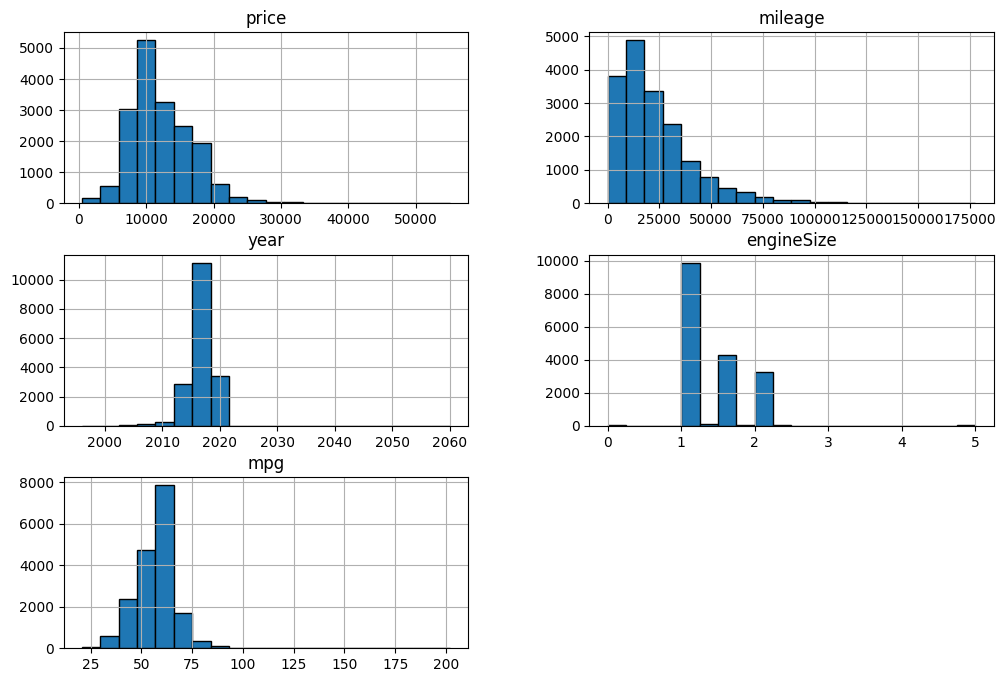

In [44]:
numeric_col = ["price", "mileage", "year", "engineSize", "mpg"]
df[numeric_col].hist(bins=20, figsize=(12, 8), edgecolor='black')
plt.show()


Analysis -

i) The disrtibution of price is mostly around 10k

ii) The distribution of mileage is around 20k

iii) The disrtibution of year is at range - 2016 - 17

iv)The distribution of engine size is at range - 1.2 to 1.8

v) The distribution of mpg is around 60 - 70


# ***Q5. (Count Plots of Categorical Features)***

/tmp/ipykernel_1687/1266747359.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette="Set2")


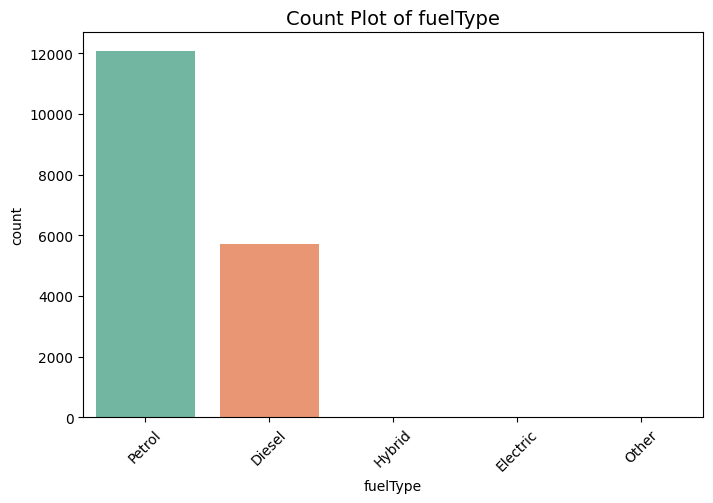

/tmp/ipykernel_1687/1266747359.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette="Set2")


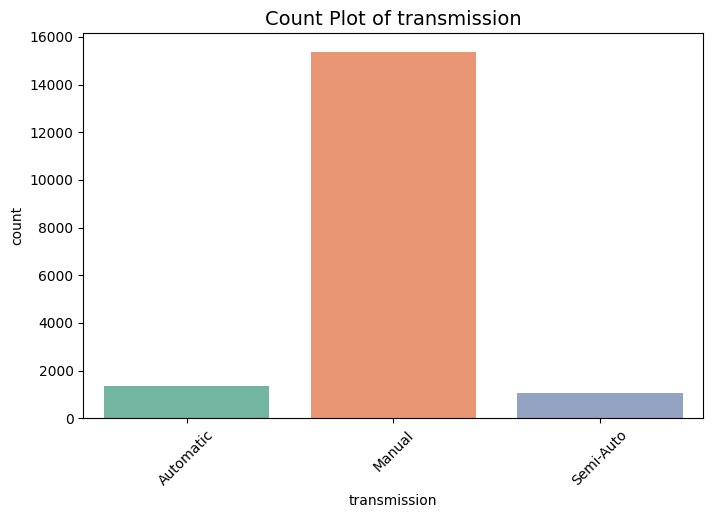

/tmp/ipykernel_1687/1266747359.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette="Set2")


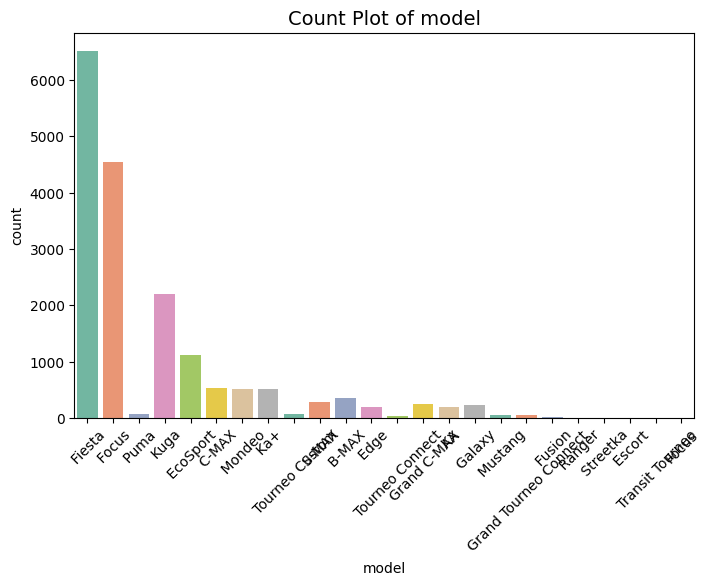

In [45]:
categorical_cols = ["fuelType", "transmission", "model"]
for col in categorical_cols:
    plt.figure(figsize=(8, 5))
    sns.countplot(data=df, x=col, palette="Set2")
    plt.title(f"Count Plot of {col}", fontsize=14)
    plt.xticks(rotation=45)
    plt.show()

**Analysis -**

i)In plot of fueltype,petrol is the most common category.

ii) In plot of transmission, Manual is the most common category.

iii) In plot of Model, Fiesta is the most common category, followed by focus.

**Market Trends -**

*  People like to drive a petrol type car with the manual  transmission more then a diesel one or the automatic one.
*  Also, models like fiesta, focus, kuga, are more common in purchasing due to they been affordable and availability.

# ***Q6. (Correlation Heatmap)***

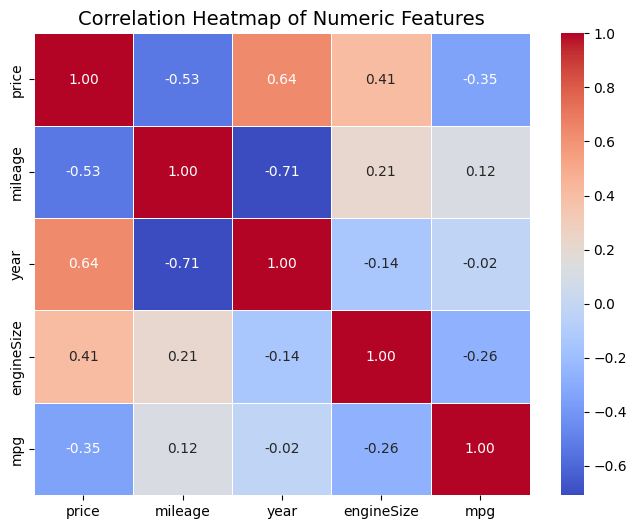

In [46]:
numeric_cols = ["price", "mileage", "year", "engineSize", "mpg"]
corr_matrix = df[numeric_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Numeric Features", fontsize=14)
plt.show()

The features that are highly correlated with the output variable (price) are -

i) year (positive correlation)

ii) enginesize (positive correlation)

iii) mpg (negative correlation)

iv) milege (negative correlation)

# ***Q7. (Feature Identification)***

**Independent Features (Input Features)** :

i) model

ii) year

iii) transmission

iv) fuelType

v) tax

vi) mpg

vii)engineSize

this all columns do affect the price of the car and are therefore must be fed to our machine learning model so that it can predict the price of the car.

***Dependent Feature (Output/Target Feature) :***

**- price**

ultimately we have to predict the price of our car therefore the output column is price..

In [47]:
df.columns

Index(['model', 'year', 'price', 'transmission', 'mileage', 'fuelType', 'tax',
       'mpg', 'engineSize'],
      dtype='object')

# ***Q8. (Encoding Categorical Variables)***

In [48]:
df = pd.DataFrame({"fuelType": ["Petrol", "Diesel", "Hybrid", "Petrol", "Diesel"],"transmission": ["Manual", "Automatic", "Manual", "Automatic", "Manual"],"price": [5000, 7000, 8000, 6000, 7500]})

print("Before Transformation:")
print(df)
df_encoded = pd.get_dummies(df, columns=["fuelType", "transmission"], drop_first=False)
print("\nAfter Transformation:")
print(df_encoded)


Before Transformation:
  fuelType transmission  price
0   Petrol       Manual   5000
1   Diesel    Automatic   7000
2   Hybrid       Manual   8000
3   Petrol    Automatic   6000
4   Diesel       Manual   7500

After Transformation:
   price  fuelType_Diesel  ...  transmission_Automatic  transmission_Manual
0   5000            False  ...                   False                 True
1   7000             True  ...                    True                False
2   8000            False  ...                   False                 True
3   6000            False  ...                    True                False
4   7500             True  ...                   False                 True

[5 rows x 6 columns]


# ***Q9. (Feature Scaling)***

In [49]:
X = df_encoded.drop("price", axis=1)
y = df_encoded["price"]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
print("First 5 rows of scaled data:")
print(X_scaled.head(5))

First 5 rows of scaled data:
   fuelType_Diesel  ...  transmission_Manual
0        -0.816497  ...             0.816497
1         1.224745  ...            -1.224745
2        -0.816497  ...             0.816497
3        -0.816497  ...            -1.224745
4         1.224745  ...             0.816497

[5 rows x 5 columns]


# ***Q10. (Mini Project - Complete Preprocessing Pipeline)***

In [50]:
print(df.shape)

(5, 3)


In [51]:
print(df.isnull().sum())

fuelType        0
transmission    0
price           0
dtype: int64


In [52]:
print(df.duplicated().sum())

0


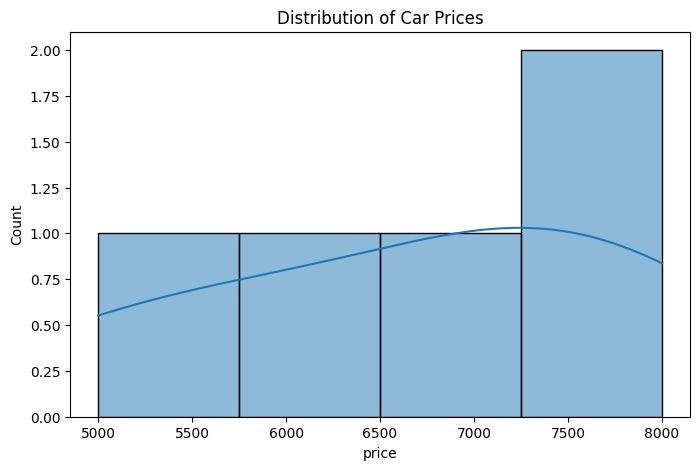

In [53]:
plt.figure(figsize=(8,5))

sns.histplot(df["price"], kde=True)

plt.title("Distribution of Car Prices")

plt.show()

In [54]:
plt.figure(figsize=(10,5))

sns.countplot(data=df, x="model")

plt.xticks(rotation=90)

plt.title("Number of Cars by Model")

plt.show()

ValueError: Could not interpret value `model` for `x`. An entry with this name does not appear in `data`.

<Figure size 1000x500 with 0 Axes>

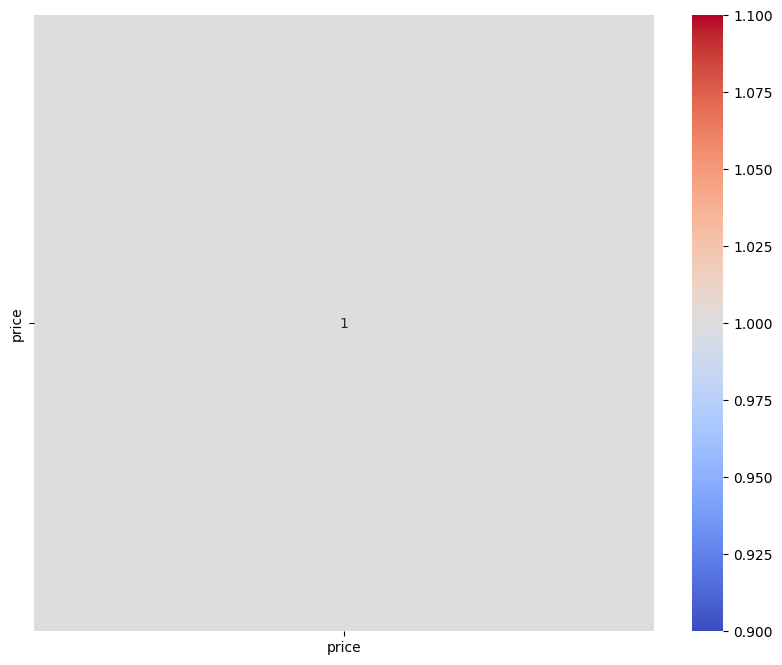

In [57]:
plt.figure(figsize=(10,8))

corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.show()

In [56]:
X = df.drop("price", axis=1)
y = df["price"]

In [55]:
print(X.dtypes)

fuelType_Diesel           bool
fuelType_Hybrid           bool
fuelType_Petrol           bool
transmission_Automatic    bool
transmission_Manual       bool
dtype: object


In [58]:
X = pd.get_dummies(X,drop_first=True)
'''Since we have actually done the scaling earlier we cannot do it again.'''